## NASA Earthdata Login credential is needed to use earthaccess package
Create `.netrc` with info below under home directory

`machine urs.earthdata.nasa.gov login [account] password [password]`

In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import earthaccess
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpcrs
import cartopy.crs as ccrs
import cartopy.feature as cft
from datetime import datetime
from matplotlib.colors import LinearSegmentedColormap
from daaq.obs_utils.obs_tools import modisaod_to_dataset

# Login your earthaccess account via .netrc file
auth = earthaccess.login(strategy="netrc")

In [2]:
def merra2_gridcell_area(lat):
    """
    Compute MERRA-2 grid-cell area for a 0.5° x 0.625° lat-lon grid.

    Parameters
    ----------
    lat : array-like
        Latitude centers in degrees (-90 to 90, step 0.5)

    Returns
    -------
    area : ndarray
        Grid-cell area in m^2 with shape (lat,)
        (same for all longitudes at a given latitude)
    """
    R = 6_371_000.0  # Earth radius [m]

    dlat = np.deg2rad(0.5)
    dlon = np.deg2rad(0.625)

    lat_rad = np.deg2rad(lat)

    area = (
        R**2
        * dlon
        * (np.sin(lat_rad + dlat / 2) - np.sin(lat_rad - dlat / 2))
    )

    return area

def domain_emission(ds, varlist):
    m2area = merra2_gridcell_area(ds.lat.values)
    area_2d = m2area[:, None]
    df = pd.DataFrame({'time': ds.time.values})
    for var in varlist:
        df[var] = (ds[var] * area_2d).sum(dim=('lat', 'lon')).values
    df = df.set_index('time')
    return df
    
def domain_average(ds, varlist):
    df = pd.DataFrame({'time': ds.time.values})
    for var in varlist:
        df[var] = ds[var].mean(dim=('lat', 'lon')).data
    df = df.set_index('time')
    return df

In [3]:
tags_dict = {
    'extinction': 'M2T1NXAER',
    'emission': 'M2T1NXADG',
}
projection = ccrs.PlateCarree()

In [4]:
# Get extinction files
ext_granules = earthaccess.search_data(short_name=tags_dict['extinction'], temporal=('2024-10-15', '2024-11-30'))
extfiles = earthaccess.open(ext_granules)

/glade/work/swei/conda-envs/swei/lib/python3.12/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/glade/work/swei/conda-envs/swei/lib/python3.12/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/47 [00:00<?, ?it/s]

In [5]:
extds = xr.open_mfdataset(extfiles)
extds

<xarray.Dataset> Size: 47GB
Dimensions:    (time: 1128, lat: 361, lon: 576)
Coordinates:
  * lon        (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * lat        (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time       (time) datetime64[ns] 9kB 2024-10-15T00:30:00 ... 2024-11-30T2...
Data variables: (12/50)
    BCANGSTR   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCCMASS    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCEXTTAU   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCFLUXU    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCFLUXV    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCSCATAU   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ...         ...
    SUFLUXU    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUFLUXV    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUSCATAU   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    TOTANGSTR  (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    TOTEXTTAU  (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    TOTSCATAU  (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Fri Oct 25 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_aer_Nx.20241015.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/KLICLTZ8EM9D
    RangeBeginningDate:                2024-10-15
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2024-10-15
    RangeEndingTime:                   23:59:59.000000

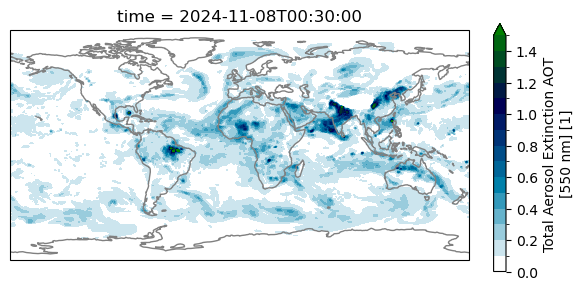

In [6]:
# Plot total AOD 2d map
plotting_date = "2024110800" 
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))
extds['TOTEXTTAU'].sel(time=datetime.strptime(plotting_date, "%Y%m%d%H"), method='nearest').plot.contourf(
    ax=ax,
    levels=np.arange(0, 1.6, 0.1),
    cmap='ocean_r',
    cbar_kwargs={'fraction':0.025}
)
ax.coastlines(color='grey')

In [7]:
extts_df = domain_average(extds, ['TOTEXTTAU'])

<Axes: xlabel='time'>

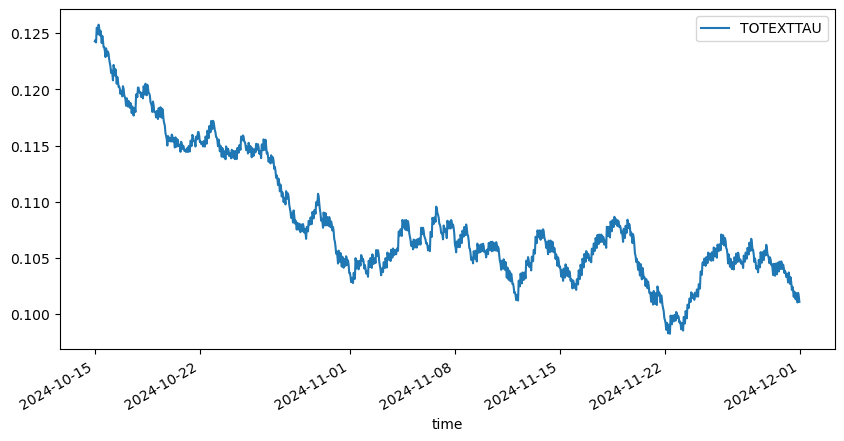

In [8]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)
extts_df.plot(ax=ax)

In [9]:
# Get emission and other diagnose files
ems_granules = earthaccess.search_data(short_name=tags_dict['emission'], temporal=('2024-10-15', '2024-11-30'))
emsfiles = earthaccess.open(ems_granules)

/glade/work/swei/conda-envs/swei/lib/python3.12/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/glade/work/swei/conda-envs/swei/lib/python3.12/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/47 [00:00<?, ?it/s]

In [10]:
ems_ds = xr.open_mfdataset(emsfiles)
ems_ds

<xarray.Dataset> Size: 108GB
Dimensions:   (time: 1128, lat: 361, lon: 576)
Coordinates:
  * lon       (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * lat       (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time      (time) datetime64[ns] 9kB 2024-10-15T00:30:00 ... 2024-11-30T23...
Data variables: (12/115)
    BCDP001   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCDP002   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCEM001   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCEM002   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCEMAN    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    BCEMBB    (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ...        ...
    SUSV003   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUSV004   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUWT001   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUWT002   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUWT003   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    SUWT004   (time, lat, lon) float32 938MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Fri Oct 25 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_adg_Nx.20241015.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/HM00OHQBHKTP
    RangeBeginningDate:                2024-10-15
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2024-10-15
    RangeEndingTime:                   23:59:59.000000

In [11]:
ems_df = domain_emission(ems_ds, ['BCEMBB', 'OCEMBB'])
ems_df['EMBB'] = ems_df['BCEMBB'] + ems_df['OCEMBB']

<Axes: xlabel='time'>

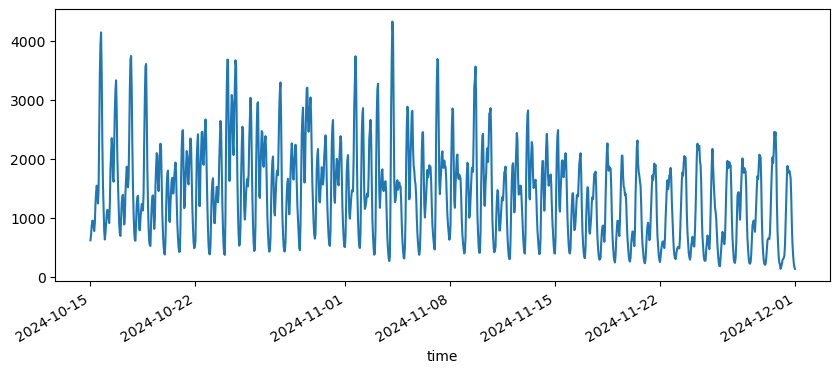

In [12]:
fig, ax = plt.subplots()
ems_df['EMBB'].plot(ax=ax, figsize=(10, 4))